# Comparative Analysis of Makam and Raga: Pitch & Scale Structure

This notebook parses one **Turkish Makam** (MusicXML) file and one **Indian Raga** (Swarlipi XML) file, converts both into semitone interval sequences, and compares their melodic/scale structures.

**Files used:**
- **Makam**: `acem--ilahi--duyek--aldanma_dunya--zekai_dede.xml` (Makam Acem, Usul Düyek)
- **Raga**: `Bhairav-1-168.xml` (Raga Bhairav, Taal Tritaal)

## 1. Import Required Libraries

In [3]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import re

sns.set_theme(style="whitegrid")

# File paths
MAKAM_FILE = "makams/acem--ilahi--duyek--aldanma_dunya--zekai_dede.xml"
RAGA_FILE = "ragas/Bhairav-1-168.xml"

print(f"Makam file exists: {os.path.exists(MAKAM_FILE)}")
print(f"Raga file exists:  {os.path.exists(RAGA_FILE)}")

Makam file exists: True
Raga file exists:  True


## 2. Load and Explore the Makam MusicXML File

The Makam file uses standard **MusicXML 3.0** (partwise) format with microtonal `<alter>` values — these are fractional semitone deviations typical of Turkish makam music (e.g., `-0.057` semitones = a Holderian comma flat).

Key elements:
- `<pitch>`: contains `<step>` (C–B), `<octave>`, and `<alter>` (microtonal deviation in semitones)
- `<duration>`: in divisions (192 divisions = quarter note in this file)
- `<rest/>`: marks rest notes
- `<tie>`: tied notes (continuation, not new onset)

In [4]:
# Parse and explore the Makam XML structure
tree = ET.parse(MAKAM_FILE)
root = tree.getroot()

print(f"Root tag: {root.tag}")
print(f"Version: {root.attrib}")

# Extract metadata
title = root.find(".//work-title")
print(f"\nTitle: {title.text if title is not None else 'N/A'}")

# Find credits for makam name and usul
for credit in root.findall(".//credit-words"):
    text = credit.text.strip() if credit.text else ""
    if text:
        print(f"Credit: {text}")

# Inspect first measure's attributes
part = root.find(".//part")
first_measure = part.find("measure")
attrs = first_measure.findall("attributes")
for attr in attrs:
    divisions = attr.find("divisions")
    if divisions is not None:
        print(f"\nDivisions per quarter: {divisions.text}")
    time_el = attr.find("time")
    if time_el is not None:
        beats = time_el.find("beats").text
        beat_type = time_el.find("beat-type").text
        print(f"Time signature: {beats}/{beat_type}")
    key_el = attr.find("key")
    if key_el is not None:
        ks = key_el.find("key-step")
        ka = key_el.find("key-alter")
        kac = key_el.find("key-accidental")
        print(f"Key: {ks.text} alter={ka.text} ({kac.text if kac is not None else ''})")

# Show first few notes
print("\n--- First 5 notes ---")
notes = first_measure.findall("note")
for i, note in enumerate(notes[:5]):
    pitch = note.find("pitch")
    if pitch is not None:
        step = pitch.find("step").text
        octave = pitch.find("octave").text
        alter = pitch.find("alter")
        alter_val = alter.text if alter is not None else "0"
        dur = note.find("duration").text
        ntype = note.find("type")
        ntype_text = ntype.text if ntype is not None else "?"
        print(f"  Note {i+1}: {step}{octave} alter={alter_val} dur={dur} type={ntype_text}")
    else:
        rest = note.find("rest")
        if rest is not None:
            dur = note.find("duration").text
            print(f"  Note {i+1}: REST dur={dur}")

Root tag: score-partwise
Version: {'version': '3.0'}

Title: Aldanma Dünya Varına
Credit: Aldanma Dünya Varına
Credit: Beste: Zekâî Dede
Credit: Sâbit
Credit: Makam: Acem İlâhî
Credit: Usul: Düyek
Credit: acem--ilahi--duyek--aldanma_dunya--zekai_dede.xml

Divisions per quarter: 192
Time signature: 8/8
Key: B alter=-0.5 (quarter-flat)

--- First 5 notes ---
  Note 1: C5 alter=-0.05660377 dur=192 type=quarter
  Note 2: F5 alter=-0.07547169 dur=144 type=eighth
  Note 3: E5 alter=0.01886793 dur=48 type=16th
  Note 4: G5 alter=-0.03773585 dur=48 type=16th
  Note 5: F5 alter=-0.07547169 dur=48 type=16th


## 3. Makam MusicXML Parser

The parser converts each MusicXML note to an absolute pitch value in **semitones** (MIDI-like):

$$\text{pitch} = (\text{octave} + 1) \times 12 + \text{step\_semitone} + \text{alter}$$

Where `step_semitone` maps C=0, D=2, E=4, F=5, G=7, A=9, B=11.

The microtonal `<alter>` values (fractions of a semitone) are preserved for accuracy — Turkish makam music uses Holderian commas (1/53 of an octave ≈ 22.6 cents).

**Tied notes** (continuation of a previous note) are skipped to avoid counting the same onset twice. **Rests** are ignored for pitch analysis. The **tonic (karar)** is determined as the last pitched note of the piece — standard in Turkish makam practice.

In [5]:
STEP_TO_SEMITONE = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}


def parse_makam_xml(filepath):
    """
    Parse a MusicXML (partwise) file from the Turkish Makam corpus.
    
    Returns:
        metadata: dict with title, makam, usul, composer
        pitches: list of absolute pitch values in semitones (with microtonal alter)
        durations: list of durations in divisions
        tonic_pitch: the karar (tonic) — last pitched note of the piece
    """
    tree = ET.parse(filepath)
    root = tree.getroot()
    
    # --- Metadata ---
    metadata = {}
    title_el = root.find(".//work-title")
    metadata["title"] = title_el.text if title_el is not None else ""
    
    composer_el = root.find(".//creator[@type='composer']")
    metadata["composer"] = composer_el.text if composer_el is not None else ""
    
    # Extract makam and usul from credits
    for credit in root.findall(".//credit-words"):
        text = (credit.text or "").strip()
        if "Makam:" in text:
            metadata["makam"] = text.replace("Makam:", "").strip()
        elif "Usul:" in text:
            metadata["usul"] = text.replace("Usul:", "").strip()
    
    # --- Parse notes ---
    pitches = []
    durations = []
    divisions = 192  # default, updated from attributes
    
    for measure in root.findall(".//part/measure"):
        # Update divisions if present
        div_el = measure.find("attributes/divisions")
        if div_el is not None:
            divisions = int(div_el.text)
        
        for note in measure.findall("note"):
            # Skip rests
            if note.find("rest") is not None:
                continue
            
            # Skip tied notes (tie type="stop" means this is a continuation)
            tie = note.find("tie")
            if tie is not None and tie.get("type") == "stop":
                # Check if there's also a start (tie chain middle) — still skip
                ties = note.findall("tie")
                types = [t.get("type") for t in ties]
                if "start" not in types:
                    continue  # pure stop = continuation only
                # If both start and stop, it's a middle of chain — skip
                continue
            
            # Extract pitch
            pitch_el = note.find("pitch")
            if pitch_el is None:
                continue
            
            step = pitch_el.find("step").text
            octave = int(pitch_el.find("octave").text)
            alter_el = pitch_el.find("alter")
            alter = float(alter_el.text) if alter_el is not None else 0.0
            
            # Convert to absolute semitone value (MIDI-like)
            # MIDI: C4 = 60, so pitch = (octave + 1) * 12 + step_semitone + alter
            abs_pitch = (octave + 1) * 12 + STEP_TO_SEMITONE[step] + alter
            
            pitches.append(abs_pitch)
            
            dur_el = note.find("duration")
            dur = int(dur_el.text) if dur_el is not None else 0
            durations.append(dur)
    
    # Tonic = last pitched note (karar in Turkish makam)
    tonic_pitch = pitches[-1] if pitches else 60
    metadata["tonic_pitch"] = tonic_pitch
    
    return metadata, pitches, durations


# Parse the makam file
makam_meta, makam_pitches, makam_durations = parse_makam_xml(MAKAM_FILE)

print("=== Makam Metadata ===")
for k, v in makam_meta.items():
    print(f"  {k}: {v}")

print(f"\nTotal notes extracted: {len(makam_pitches)}")
print(f"Pitch range: {min(makam_pitches):.2f} - {max(makam_pitches):.2f} semitones")
print(f"Tonic (karar): {makam_meta['tonic_pitch']:.2f} semitones")
print(f"\nFirst 20 pitches: {[f'{p:.2f}' for p in makam_pitches[:20]]}")

=== Makam Metadata ===
  title: Aldanma Dünya Varına
  composer: Beste: Zekâî Dede
  makam: Acem İlâhî
  usul: Düyek
  tonic_pitch: 69.0

Total notes extracted: 129
Pitch range: 66.96 - 81.00 semitones
Tonic (karar): 69.00 semitones

First 20 pitches: ['71.94', '76.92', '76.02', '78.96', '76.92', '76.92', '76.02', '76.92', '76.02', '76.92', '76.02', '73.98', '76.02', '76.92', '76.02', '73.98', '71.94', '73.98', '76.02', '76.92']


## 4. Load and Explore the Swarlipi (Raga) File

The Swarlipi file uses a custom XML schema (`<swarlipi>`) based on the **Bhatkhande notation system**. Key sections:

- `<RAAG>`: Raga name, thaat, arohana/avarohana (ascending/descending scale), vadi/samvadi (dominant/subdominant)
- `<TAAL>`: Rhythmic cycle (taal name, number of beats, structure)
- `<SHEET>`: The actual notation — a grid of **lines → rows → columns → content cells**

Each `<COL>` content cell (e.g., `"R g R g"`) contains space-separated swar symbols where each symbol gets an **equal subdivision** of the beat.

In [6]:
# Parse and explore the Swarlipi XML structure
tree_raga = ET.parse(RAGA_FILE)
root_raga = tree_raga.getroot()

print(f"Root tag: {root_raga.tag}\n")

# Raga metadata
raag = root_raga.find("RAAG")
print("=== Raga Info ===")
for child in raag:
    print(f"  {child.tag}: {child.text}")

# Taal metadata
taal = root_raga.find("TAAL")
print("\n=== Taal Info ===")
for child in taal:
    print(f"  {child.tag}: {child.text}")

# Sheet structure
sheet = root_raga.find("SHEET")
total_lines = sheet.find("TOTAL_LINES").text
print(f"\n=== Sheet ===")
print(f"Total lines: {total_lines}")

# Show all content cells
lines = sheet.find("LINES")
print("\n--- All content cells ---")
for line in lines.findall("LINE"):
    line_idx = line.get("INDEX")
    for row in line.findall("ROW"):
        cells = []
        for col in row.findall("COL"):
            cells.append(col.find("CONTENT").text)
        print(f"  Line {line_idx}: {cells}")

Root tag: swarlipi

=== Raga Info ===
  RAAG_NAME: Bhairav
  THAAT: Bhairav
  AROHANA: s-R-g-m-p-D-n-su
  AVAROHANA: su-n-D-p-m-g-R-s
  VADI: D
  SAMVADI: R
  JAATI: Sampoorna-Sampoorna
  PAKAD: s-g-m-p-D-p

=== Taal Info ===
  TAAL_NAME: Tritaal
  BIBHAGA: 4
  MAATRA: 16
  AVARTANA: 1
  BEAT_PATTERN: 4-4-4-4
  ALTERNATE_BEAT_PATTERN: NA
  TAALI_COUNT: 3
  KHALI_COUNT: 1
  TAALI_INDEX: 1-5-13
  KHALI_INDEX: 9

=== Sheet ===
Total lines: 7

--- All content cells ---
  Line 0: ['R g R g', 'm p g m', 'n D - g', '- m g R']
  Line 1: ['g m p g', 'm n D  -', 'Ru - su gu', '- g - m']
  Line 2: ['n D Ru -', 'D - R -', 'g m p g', 'm g R n']
  Line 3: ['g g p p', 'D D n n', 'D n n D', 'm p gu mu']
  Line 4: ['D - n D', '- R -  mu', 'gu - Ru  -', 'pu - gu  mu']
  Line 5: ['D -  D -', 'n D -  n', 'Ru gu n  Ru', 'D n m D']
  Line 6: ['g m p  g', 'm g R  n']


## 5. Swarlipi Symbol-to-Semitone Mapping

The mapping strategy uses the **thaat** (parent scale) to determine exact semitone intervals for each swar:

| Swar | Position | Bhairav Thaat | Semitones from Sa |
|------|----------|---------------|-------------------|
| s/S  | Sa       | Tonic         | 0                 |
| R    | Re       | Komal Re      | 1                 |
| g    | Ga       | Shuddha Ga   | 4                 |
| m    | Ma       | Shuddha Ma   | 5                 |
| p/P  | Pa       | Pa            | 7                 |
| D    | Dha      | Komal Dha     | 8                 |
| n    | Ni       | Shuddha Ni   | 11                |

**Octave handling**: Suffix `u` = upper octave (+12), suffix `l` = lower octave (−12).  
A `-` symbol = sustain (previous pitch continues).

The swar symbol's base letter (case-insensitive) identifies which scale degree it is; the thaat determines its exact interval. This generalises to other ragas/thaats.

In [7]:
# --- Thaat definitions: semitone intervals for each swar position ---
# Each thaat defines [Sa, Re, Ga, Ma, Pa, Dha, Ni] in semitones from Sa
THAAT_INTERVALS = {
    "Bilawal":  [0, 2, 4, 5, 7, 9, 11],   # Major scale
    "Khamaj":   [0, 2, 4, 5, 7, 9, 10],
    "Kafi":     [0, 2, 3, 5, 7, 9, 10],
    "Asavari":  [0, 2, 3, 5, 7, 8, 10],
    "Bhairavi": [0, 1, 3, 5, 7, 8, 10],
    "Bhairav":  [0, 1, 4, 5, 7, 8, 11],
    "Kalyan":   [0, 2, 4, 6, 7, 9, 11],
    "Marwa":    [0, 1, 4, 6, 7, 9, 11],
    "Poorvi":   [0, 1, 4, 6, 7, 8, 11],
    "Todi":     [0, 1, 3, 6, 7, 8, 11],
}

# Swar base letters → position index (0-6 in the sargam)
SWAR_BASE_TO_INDEX = {
    "s": 0, "S": 0,
    "r": 1, "R": 1,
    "g": 2, "G": 2,
    "m": 3, "M": 3,
    "p": 4, "P": 4,
    "d": 5, "D": 5,
    "n": 6, "N": 6,
}


def build_swar_mapping(thaat_name):
    """
    Build a mapping from swar symbol → semitone interval from Sa,
    based on the thaat definition.
    
    Handles octave suffixes: 'u' = upper (+12), 'l' = lower (-12)
    """
    intervals = THAAT_INTERVALS[thaat_name]
    mapping = {}
    
    # Build for each possible swar letter (both cases)
    for letter, idx in SWAR_BASE_TO_INDEX.items():
        # Middle octave (mandra/madhya)
        mapping[letter] = intervals[idx]
        # Upper octave suffix
        mapping[letter + "u"] = intervals[idx] + 12
        # Lower octave suffix
        mapping[letter + "l"] = intervals[idx] - 12
    
    return mapping


# Build mapping for Bhairav thaat
bhairav_mapping = build_swar_mapping("Bhairav")

print("=== Bhairav Swar → Semitone Mapping ===")
# Display middle octave only
for swar in ["s", "R", "g", "m", "p", "D", "n"]:
    print(f"  {swar:>2s} → {bhairav_mapping[swar]:>2d} semitones")
print("\n  Upper octave examples:")
for swar in ["su", "Ru", "gu", "mu"]:
    print(f"  {swar:>2s} → {bhairav_mapping[swar]:>2d} semitones")

=== Bhairav Swar → Semitone Mapping ===
   s →  0 semitones
   R →  1 semitones
   g →  4 semitones
   m →  5 semitones
   p →  7 semitones
   D →  8 semitones
   n → 11 semitones

  Upper octave examples:
  su → 12 semitones
  Ru → 13 semitones
  gu → 16 semitones
  mu → 17 semitones


## 6. Swarlipi Parser

The parser reads each `<COL>` content cell (e.g., `"R g R g"`), splits on whitespace to get tokens, and maps each token to its semitone interval.

**Beat cell subdivision**: Each cell in the taal grid gets one beat. If a cell has N swar symbols, each gets 1/N of the beat duration (equal subdivision).

**Special tokens**:
- `-` = sustain (holds previous pitch)
- Empty/whitespace = skip

In [8]:
def parse_swarlipi(filepath):
    """
    Parse a Swarlipi XML file and extract pitch information.
    
    Returns:
        metadata: dict with raga name, thaat, arohana, avarohana, taal, etc.
        pitches: list of semitone intervals from Sa (with sustains resolved)
        beat_fractions: list of beat-fraction durations for each note
    """
    tree = ET.parse(filepath)
    root = tree.getroot()
    
    # --- Metadata ---
    metadata = {}
    info = root.find("INFO")
    if info is not None:
        metadata["title"] = (info.find("TITLE").text or "").strip()
        metadata["composer"] = (info.find("COMPOSER").text or "").strip()
        metadata["year"] = (info.find("YEAR").text or "").strip()
    
    raag = root.find("RAAG")
    metadata["raga"] = (raag.find("RAAG_NAME").text or "").strip()
    metadata["thaat"] = (raag.find("THAAT").text or "").strip()
    metadata["arohana"] = (raag.find("AROHANA").text or "").strip()
    metadata["avarohana"] = (raag.find("AVAROHANA").text or "").strip()
    metadata["vadi"] = (raag.find("VADI").text or "").strip()
    metadata["samvadi"] = (raag.find("SAMVADI").text or "").strip()
    
    taal = root.find("TAAL")
    metadata["taal"] = (taal.find("TAAL_NAME").text or "").strip()
    metadata["maatra"] = int(taal.find("MAATRA").text)
    metadata["beat_pattern"] = (taal.find("BEAT_PATTERN").text or "").strip()
    
    # --- Build swar mapping from thaat ---
    swar_map = build_swar_mapping(metadata["thaat"])
    
    # --- Parse sheet content ---
    pitches = []       # semitone intervals from Sa
    beat_fracs = []    # duration as fraction of beat
    
    sheet = root.find("SHEET")
    lines = sheet.find("LINES")
    
    last_pitch = 0  # for sustain resolution (default to Sa)
    
    for line in lines.findall("LINE"):
        for row in line.findall("ROW"):
            for col in row.findall("COL"):
                content = col.find("CONTENT").text
                if content is None:
                    continue
                
                # Tokenize: split on whitespace
                tokens = content.split()
                n_tokens = len(tokens)
                if n_tokens == 0:
                    continue
                
                # Each token gets 1/N of the beat
                frac = 1.0 / n_tokens
                
                for token in tokens:
                    token = token.strip()
                    if not token:
                        continue
                    
                    if token == "-":
                        # Sustain: hold previous pitch
                        pitches.append(last_pitch)
                        beat_fracs.append(frac)
                    elif token in swar_map:
                        pitch = swar_map[token]
                        pitches.append(pitch)
                        beat_fracs.append(frac)
                        last_pitch = pitch
                    else:
                        # Unknown token — try to parse it
                        # Could be a compound or ornamental marker
                        print(f"  [WARN] Unknown token: '{token}' — skipping")
    
    return metadata, pitches, beat_fracs


# Parse the raga file
raga_meta, raga_pitches, raga_beat_fracs = parse_swarlipi(RAGA_FILE)

print("=== Raga Metadata ===")
for k, v in raga_meta.items():
    print(f"  {k}: {v}")

print(f"\nTotal notes/events: {len(raga_pitches)}")
print(f"Pitch range: {min(raga_pitches)} - {max(raga_pitches)} semitones from Sa")
print(f"\nFirst 30 pitches (semitones from Sa):")
print(f"  {raga_pitches[:30]}")

=== Raga Metadata ===
  title: Composition 107 Volume 2 Kramik Pustak Malika
  composer: Vishnu Narayan Bhatkhande
  year: 1923
  raga: Bhairav
  thaat: Bhairav
  arohana: s-R-g-m-p-D-n-su
  avarohana: su-n-D-p-m-g-R-s
  vadi: D
  samvadi: R
  taal: Tritaal
  maatra: 16
  beat_pattern: 4-4-4-4

Total notes/events: 104
Pitch range: 1 - 19 semitones from Sa

First 30 pitches (semitones from Sa):
  [1, 4, 1, 4, 5, 7, 4, 5, 11, 8, 8, 4, 4, 5, 4, 1, 4, 5, 7, 4, 5, 11, 8, 8, 13, 13, 12, 16, 16, 4]


## 7. Normalize Both to Semitone Interval Sequences

Now we convert both pitch sequences into a common representation: **sequential semitone intervals** (pitch[i+1] − pitch[i]).

For the Makam pitches (which are absolute semitones), we first convert to **intervals from the tonic**, then compute sequential differences. This makes both datasets comparable — both now represent melodic motion in semitones relative to their respective tonics.

In [9]:
def compute_intervals(pitches):
    """Compute sequential semitone intervals from a pitch sequence."""
    return [pitches[i+1] - pitches[i] for i in range(len(pitches) - 1)]


def pitch_classes_from_tonic(pitches, tonic):
    """Convert absolute pitches to semitone intervals from tonic (mod 12 for pitch class)."""
    return [(p - tonic) % 12 for p in pitches]


# --- Makam: convert to intervals from tonic ---
makam_tonic = makam_meta["tonic_pitch"]
makam_relative = [p - makam_tonic for p in makam_pitches]  # signed interval from tonic
makam_pitch_classes = pitch_classes_from_tonic(makam_pitches, round(makam_tonic))
makam_intervals = compute_intervals(makam_relative)

# --- Raga: already in semitones from Sa ---
raga_relative = raga_pitches  # already relative to Sa
raga_pitch_classes = [p % 12 for p in raga_pitches]
raga_intervals = compute_intervals(raga_relative)

# --- Build combined DataFrame ---
max_len = max(len(makam_intervals), len(raga_intervals))

df_intervals = pd.DataFrame({
    "position": list(range(len(makam_intervals))) + list(range(len(raga_intervals))),
    "interval": makam_intervals + raga_intervals,
    "source": ["Makam"] * len(makam_intervals) + ["Raga"] * len(raga_intervals),
})

# --- Summary statistics ---
print("=" * 60)
print(f"{'Metric':<30} {'Makam':>12} {'Raga':>12}")
print("=" * 60)
print(f"{'Pitch sequence length':<30} {len(makam_pitches):>12} {len(raga_pitches):>12}")
print(f"{'Interval sequence length':<30} {len(makam_intervals):>12} {len(raga_intervals):>12}")
print(f"{'Min interval (semitones)':<30} {min(makam_intervals):>12.2f} {min(raga_intervals):>12.2f}")
print(f"{'Max interval (semitones)':<30} {max(makam_intervals):>12.2f} {max(raga_intervals):>12.2f}")
print(f"{'Mean interval':<30} {np.mean(makam_intervals):>12.2f} {np.mean(raga_intervals):>12.2f}")
print(f"{'Std deviation':<30} {np.std(makam_intervals):>12.2f} {np.std(raga_intervals):>12.2f}")
print(f"{'Mean |interval| (abs)':<30} {np.mean(np.abs(makam_intervals)):>12.2f} {np.mean(np.abs(raga_intervals)):>12.2f}")
print("=" * 60)

# Pitch class usage
print("\n--- Unique pitch classes used (semitones from tonic, mod 12) ---")
makam_pcs = sorted(set([round(pc, 1) for pc in makam_pitch_classes]))
raga_pcs = sorted(set(raga_pitch_classes))
print(f"  Makam: {makam_pcs}")
print(f"  Raga:  {raga_pcs}")

Metric                                Makam         Raga
Pitch sequence length                   129          104
Interval sequence length                128          103
Min interval (semitones)              -4.98       -12.00
Max interval (semitones)               9.06        16.00
Mean interval                         -0.02         0.10
Std deviation                          2.36         4.02
Mean |interval| (abs)                  1.82         2.80

--- Unique pitch classes used (semitones from tonic, mod 12) ---
  Makam: [0.0, 1.6, 2.9, 5.0, 7.0, 7.9, 10.0]
  Raga:  [0, 1, 4, 5, 7, 8, 11]


## 8. Compare Interval Patterns

Quantitative comparison:
1. **Interval frequency distributions** — which intervals dominate each tradition?
2. **Interval bigrams** — what are the most common two-step melodic motions?
3. **Cosine similarity** of interval distributions — how similar are the overall motion patterns?

In [10]:
def cosine_similarity(counter1, counter2):
    """Cosine similarity between two Counter distributions."""
    all_keys = set(counter1.keys()) | set(counter2.keys())
    v1 = np.array([counter1.get(k, 0) for k in all_keys], dtype=float)
    v2 = np.array([counter2.get(k, 0) for k in all_keys], dtype=float)
    dot = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / norm if norm > 0 else 0.0


# Round makam intervals to nearest semitone for comparison
makam_intervals_rounded = [round(iv) for iv in makam_intervals]
raga_intervals_rounded = [round(iv) for iv in raga_intervals]

# --- Interval frequency ---
makam_int_counts = Counter(makam_intervals_rounded)
raga_int_counts = Counter(raga_intervals_rounded)

print("=== Most Common Intervals (semitones) ===\n")
print(f"{'Makam (top 10)':<35} {'Raga (top 10)':<35}")
print("-" * 70)
m_common = makam_int_counts.most_common(10)
r_common = raga_int_counts.most_common(10)
for i in range(10):
    m_str = f"{m_common[i][0]:>+3d}: {m_common[i][1]:>3d}x" if i < len(m_common) else ""
    r_str = f"{r_common[i][0]:>+3d}: {r_common[i][1]:>3d}x" if i < len(r_common) else ""
    print(f"  {m_str:<33} {r_str:<33}")

# --- Categorize intervals ---
def categorize_intervals(intervals):
    ascending = sum(1 for iv in intervals if iv > 0)
    descending = sum(1 for iv in intervals if iv < 0)
    unison = sum(1 for iv in intervals if iv == 0)
    return ascending, descending, unison

m_asc, m_desc, m_uni = categorize_intervals(makam_intervals_rounded)
r_asc, r_desc, r_uni = categorize_intervals(raga_intervals_rounded)

print(f"\n{'Motion type':<20} {'Makam':>10} {'Makam %':>10} {'Raga':>10} {'Raga %':>10}")
print("-" * 60)
m_total = len(makam_intervals_rounded)
r_total = len(raga_intervals_rounded)
print(f"{'Ascending':<20} {m_asc:>10} {100*m_asc/m_total:>9.1f}% {r_asc:>10} {100*r_asc/r_total:>9.1f}%")
print(f"{'Descending':<20} {m_desc:>10} {100*m_desc/m_total:>9.1f}% {r_desc:>10} {100*r_desc/r_total:>9.1f}%")
print(f"{'Unison (repeat)':<20} {m_uni:>10} {100*m_uni/m_total:>9.1f}% {r_uni:>10} {100*r_uni/r_total:>9.1f}%")

# --- Cosine similarity ---
cos_sim = cosine_similarity(makam_int_counts, raga_int_counts)
print(f"\nCosine similarity of interval distributions: {cos_sim:.4f}")

# --- Bigrams (consecutive interval pairs) ---
def get_bigrams(intervals):
    return [(intervals[i], intervals[i+1]) for i in range(len(intervals) - 1)]

makam_bigrams = Counter(get_bigrams(makam_intervals_rounded))
raga_bigrams = Counter(get_bigrams(raga_intervals_rounded))

print("\n=== Top 10 Interval Bigrams ===\n")
print(f"{'Makam':<35} {'Raga':<35}")
print("-" * 70)
m_bg = makam_bigrams.most_common(10)
r_bg = raga_bigrams.most_common(10)
for i in range(10):
    m_str = f"({m_bg[i][0][0]:>+2d},{m_bg[i][0][1]:>+2d}): {m_bg[i][1]:>3d}x" if i < len(m_bg) else ""
    r_str = f"({r_bg[i][0][0]:>+2d},{r_bg[i][0][1]:>+2d}): {r_bg[i][1]:>3d}x" if i < len(r_bg) else ""
    print(f"  {m_str:<33} {r_str:<33}")

# Bigram cosine similarity
bg_cos_sim = cosine_similarity(makam_bigrams, raga_bigrams)
print(f"\nCosine similarity of bigram distributions: {bg_cos_sim:.4f}")

=== Most Common Intervals (semitones) ===

Makam (top 10)                      Raga (top 10)                      
----------------------------------------------------------------------
   -2:  40x                          +0:  24x                        
   -1:  28x                          -3:  18x                        
   +2:  18x                          +3:  13x                        
   +1:  15x                          +1:  13x                        
   +0:  13x                          +2:   7x                        
   +5:   6x                          -1:   5x                        
   +3:   3x                          +6:   4x                        
   -5:   2x                          -5:   3x                        
   +8:   2x                          -7:   3x                        
   +9:   1x                          -4:   2x                        

Motion type               Makam    Makam %       Raga     Raga %
------------------------------------------------

## 9. Visualize Interval Distributions and Sequential Patterns

/var/folders/py/_v9bd7p13qg3g1c_8mtg56pr0000gn/T/ipykernel_15512/1860948462.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Source", y="Interval (semitones)", data=data_box, palette=palette, ax=ax)


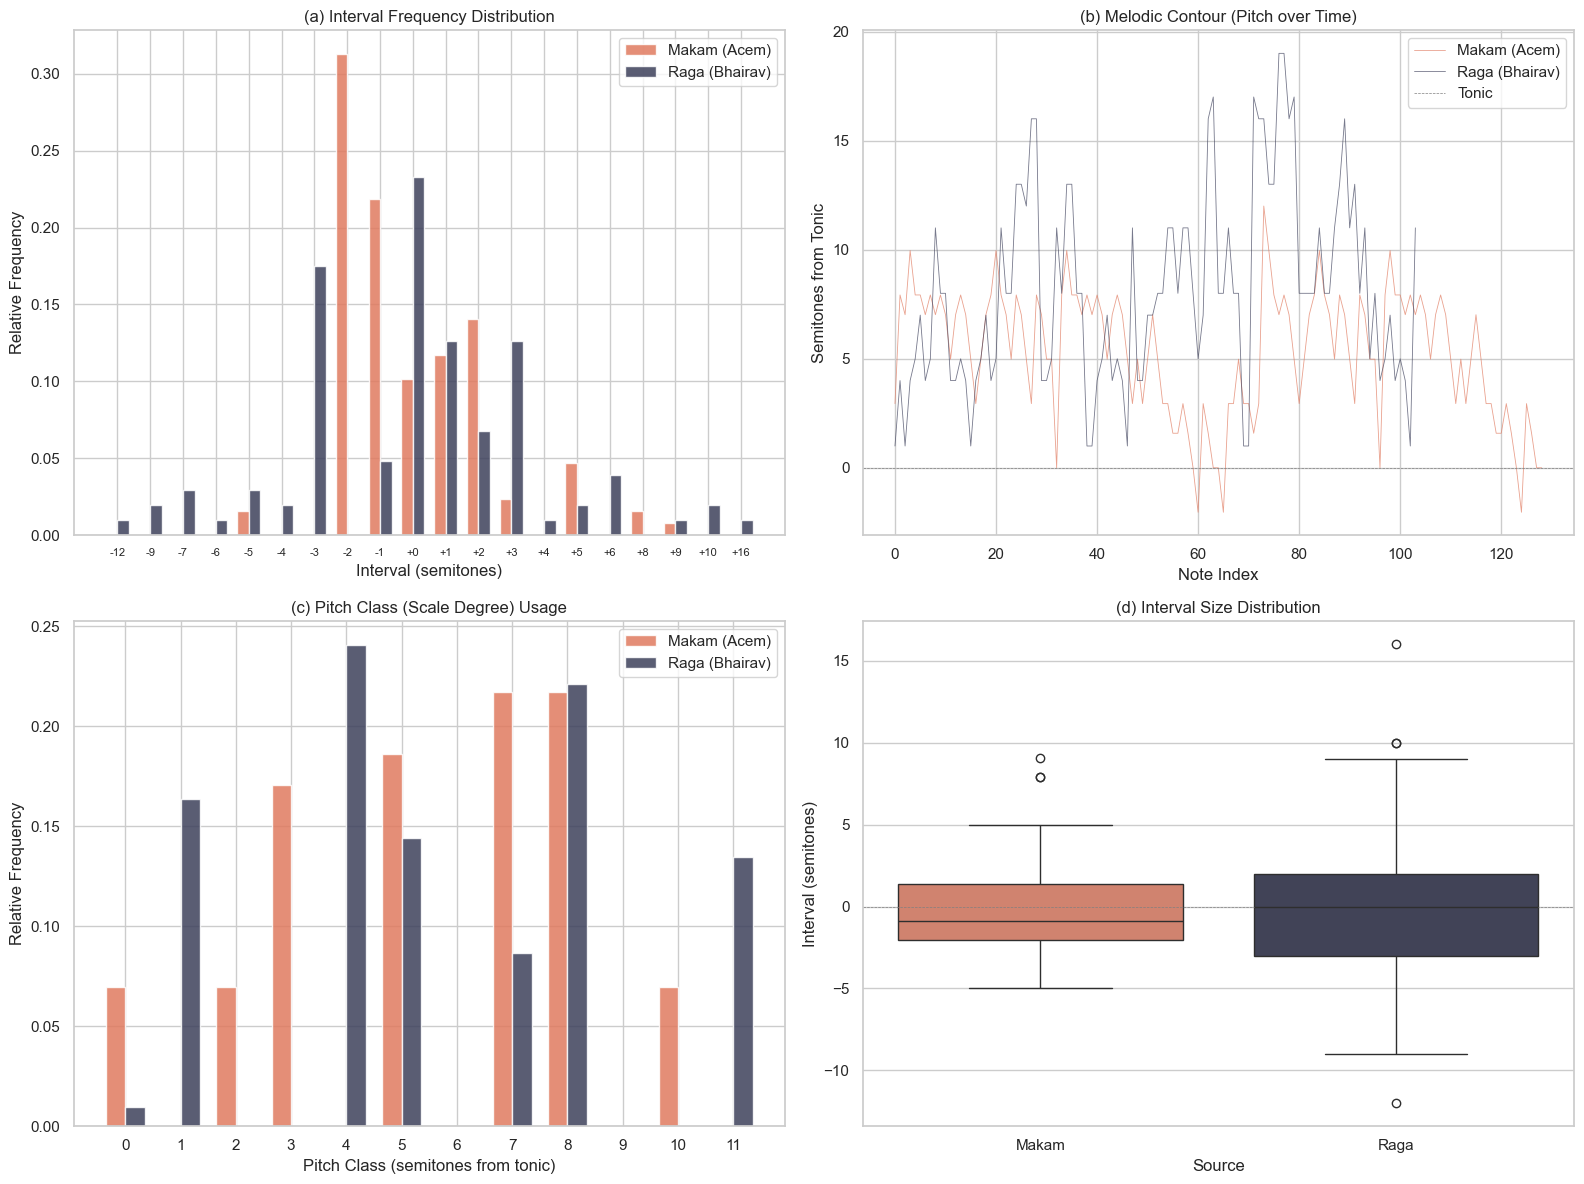

Saved: interval_comparison.png


In [ ]:
MAKAM_COLOR = "#E07A5F"   # terracotta
RAGA_COLOR = "#3D405B"    # dark blue

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- (1) Interval Frequency Histogram ----
ax = axes[0, 0]
all_ints = sorted(set(makam_intervals_rounded) | set(raga_intervals_rounded))
x = np.arange(len(all_ints))
width = 0.35

m_vals = [makam_int_counts.get(iv, 0) / m_total for iv in all_ints]
r_vals = [raga_int_counts.get(iv, 0) / r_total for iv in all_ints]

ax.bar(x - width/2, m_vals, width, label="Makam (Acem)", color=MAKAM_COLOR, alpha=0.85)
ax.bar(x + width/2, r_vals, width, label="Raga (Bhairav)", color=RAGA_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"{iv:+d}" for iv in all_ints], fontsize=8)
ax.set_xlabel("Interval (semitones)")
ax.set_ylabel("Relative Frequency")
ax.set_title("(a) Interval Frequency Distribution")
ax.legend()

# ---- (2) Melodic Contour (cumulative pitch over time) ----
ax = axes[0, 1]
# Normalize both to start at 0 (tonic) and show relative pitch over time
ax.plot(makam_relative, color=MAKAM_COLOR, alpha=0.7, linewidth=0.6, label="Makam (Acem)")
ax.plot(raga_relative, color=RAGA_COLOR, alpha=0.7, linewidth=0.6, label="Raga (Bhairav)")
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5, label="Tonic")
ax.set_xlabel("Note Index")
ax.set_ylabel("Semitones from Tonic")
ax.set_title("(b) Melodic Contour (Pitch over Time)")
ax.legend()

# ---- (3) Pitch Class Distribution (scale usage) ----
ax = axes[1, 0]
# For makam: round to nearest semitone class
makam_pc_rounded = [round(pc) % 12 for pc in makam_pitch_classes]
raga_pc_list = [pc % 12 for pc in raga_pitch_classes]

pc_labels = list(range(12))
m_pc_counts = Counter(makam_pc_rounded)
r_pc_counts = Counter(raga_pc_list)

m_pc_vals = [m_pc_counts.get(pc, 0) / len(makam_pc_rounded) for pc in pc_labels]
r_pc_vals = [r_pc_counts.get(pc, 0) / len(raga_pc_list) for pc in pc_labels]

x_pc = np.arange(12)
ax.bar(x_pc - width/2, m_pc_vals, width, label="Makam (Acem)", color=MAKAM_COLOR, alpha=0.85)
ax.bar(x_pc + width/2, r_pc_vals, width, label="Raga (Bhairav)", color=RAGA_COLOR, alpha=0.85)
ax.set_xticks(x_pc)
ax.set_xticklabels(x_pc)
ax.set_xlabel("Pitch Class (semitones from tonic)")
ax.set_ylabel("Relative Frequency")
ax.set_title("(c) Pitch Class (Scale Degree) Usage")
ax.legend()

# ---- (4) Box Plot of Interval Sizes ----
ax = axes[1, 1]
data_box = pd.DataFrame({
    "Interval (semitones)": makam_intervals + raga_intervals,
    "Source": ["Makam"] * len(makam_intervals) + ["Raga"] * len(raga_intervals),
})
palette = {"Makam": MAKAM_COLOR, "Raga": RAGA_COLOR}
sns.boxplot(x="Source", y="Interval (semitones)", data=data_box, palette=palette, ax=ax)
ax.set_title("(d) Interval Size Distribution")
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

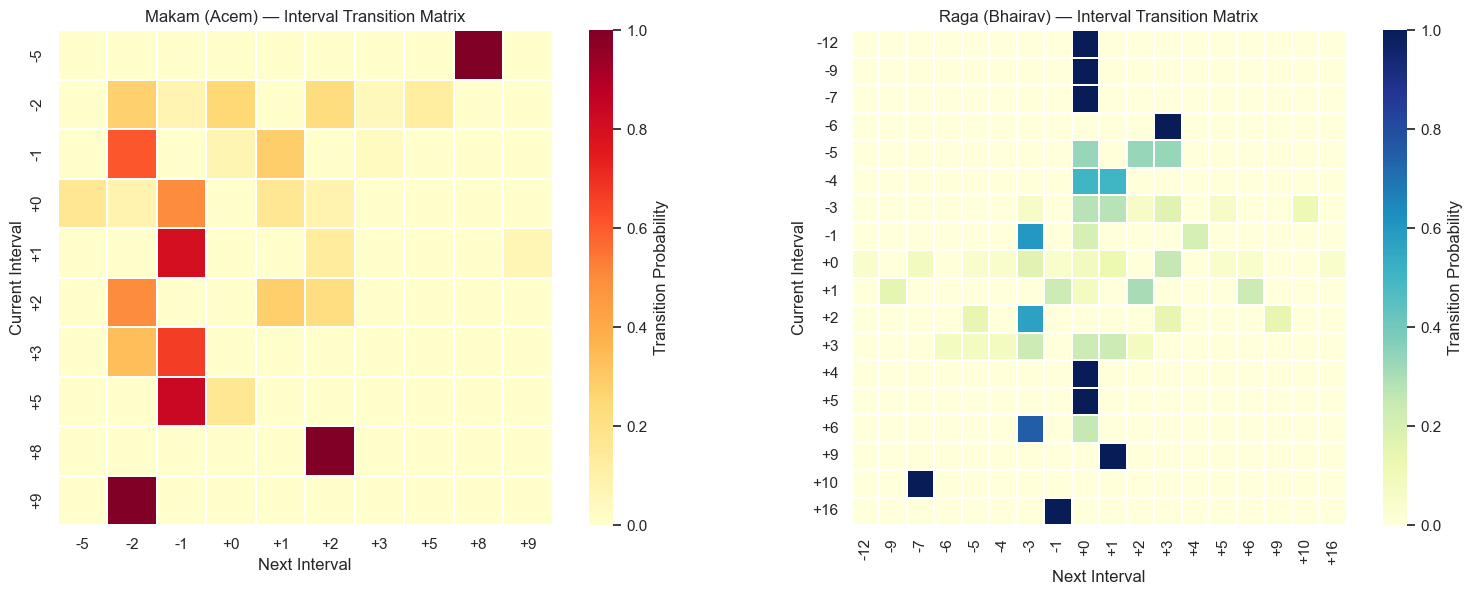

Saved: transition_matrices.png


In [ ]:
# ---- Interval Bigram Transition Heatmaps ----
def build_transition_matrix(intervals_rounded, label=""):
    """Build a transition count matrix from interval bigrams."""
    unique_intervals = sorted(set(intervals_rounded))
    idx_map = {iv: i for i, iv in enumerate(unique_intervals)}
    n = len(unique_intervals)
    matrix = np.zeros((n, n))
    
    for i in range(len(intervals_rounded) - 1):
        r = idx_map[intervals_rounded[i]]
        c = idx_map[intervals_rounded[i+1]]
        matrix[r, c] += 1
    
    # Normalize rows to get transition probabilities
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    matrix_norm = matrix / row_sums
    
    return matrix_norm, unique_intervals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Makam transition matrix
m_matrix, m_labels = build_transition_matrix(makam_intervals_rounded)
sns.heatmap(m_matrix, xticklabels=[f"{l:+d}" for l in m_labels],
            yticklabels=[f"{l:+d}" for l in m_labels],
            cmap="YlOrRd", ax=ax1, square=True, linewidths=0.3,
            cbar_kws={"label": "Transition Probability"})
ax1.set_title("Makam (Acem) — Interval Transition Matrix")
ax1.set_xlabel("Next Interval")
ax1.set_ylabel("Current Interval")

# Raga transition matrix
r_matrix, r_labels = build_transition_matrix(raga_intervals_rounded)
sns.heatmap(r_matrix, xticklabels=[f"{l:+d}" for l in r_labels],
            yticklabels=[f"{l:+d}" for l in r_labels],
            cmap="YlGnBu", ax=ax2, square=True, linewidths=0.3,
            cbar_kws={"label": "Transition Probability"})
ax2.set_title("Raga (Bhairav) — Interval Transition Matrix")
ax2.set_xlabel("Next Interval")
ax2.set_ylabel("Current Interval")

plt.tight_layout()
plt.show()


## Summary

**What each parser does:**

- **`parse_makam_xml()`**: Reads MusicXML `<note>` → `<pitch>` elements, combines `<step>`, `<octave>`, `<alter>` (microtonal) into absolute semitone values, skips tied continuations and rests, determines tonic from the final note (karar).

- **`parse_swarlipi()`**: Reads the `<SHEET>` grid of content cells, uses the `<THAAT>` to build a swar→semitone mapping, tokenizes each cell with equal beat subdivisions, resolves sustain dashes.

**Common representation:** Both are converted to sequences of **semitone intervals from tonic**, then **sequential differences** (melodic intervals) are computed for comparison.

**Next steps for extending this analysis:**
- Batch process all files in each directory for aggregate statistics
- Add duration-weighted pitch distributions  
- Compute pitch contour similarity (e.g., Dynamic Time Warping)
- Analyze ornamental patterns (grace notes, gamakas vs çarpma/glissando)